# Credit Card Fraud Detection


## Step 1: Install Libraries

In [4]:
!pip install pandas numpy matplotlib seaborn scikit-learn

### Step 2: Import Libraries

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

## Step 3: Load Dataset

In [10]:
df = pd.read_csv("creditcard.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


## Step 4: View Dataset

In [13]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Step 5: Dataset Shape

In [16]:
print("Dataset Shape:", df.shape)

Dataset Shape: (284807, 31)


## Step 6: Check Missing Values

In [19]:
df.isnull().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

## Step 7: Class Distribution

In [22]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

## Step 8: Plot Fraud vs Normal Transactions

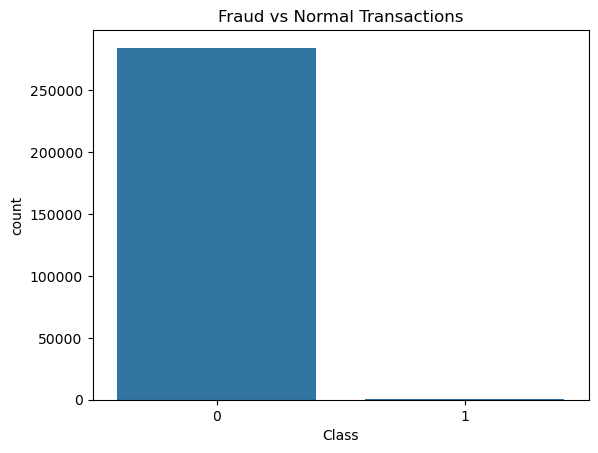

In [25]:
sns.countplot(x='Class', data=df)

plt.title("Fraud vs Normal Transactions")

plt.show()

## Step 9: Split Features and Target

In [28]:
X = df.drop('Class', axis=1)

y = df['Class']

## Step 10: Feature Scaling

In [31]:
scaler = StandardScaler()

X['Amount'] = scaler.fit_transform(X[['Amount']])

X['Time'] = scaler.fit_transform(X[['Time']])

## Step 11: Train-Test Split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (227845, 30)
Testing Shape: (56962, 30)


## Step 12: Logistic Regression

In [39]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, lr_pred))

print("\nConfusion Matrix:")

print(confusion_matrix(y_test, lr_pred))

print("\nClassification Report:")

print(classification_report(y_test, lr_pred))

Accuracy: 0.9991573329588147

Confusion Matrix:
[[56851    13]
 [   35    63]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.64      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962



## Step 13: Decision Tree

In [44]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, dt_pred))

print("\nConfusion Matrix:")

print(confusion_matrix(y_test, dt_pred))

print("\nClassification Report:")

print(classification_report(y_test, dt_pred))

Accuracy: 0.9991397773954567

Confusion Matrix:
[[56840    24]
 [   25    73]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.75      0.74      0.75        98

    accuracy                           1.00     56962
   macro avg       0.88      0.87      0.87     56962
weighted avg       1.00      1.00      1.00     56962



## Step 14: Random Forest

In [48]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Accuracy:",
      accuracy_score(y_test, rf_pred))

print("\nConfusion Matrix:")

print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:")

print(classification_report(y_test, rf_pred))

Accuracy: 0.9995962220427653

Confusion Matrix:
[[56859     5]
 [   18    80]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



## Step 15: Compare Models

In [59]:
models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest'
]

accuracies = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred)
]

comparison = pd.DataFrame({
    'Model': models,
    'Accuracy': accuracies
})

comparison

,Model,Accuracy
0,Logistic Regression,0.999157
1,Decision Tree,0.999140
2,Random Forest,0.999596


## Step 16: Accuracy Graph

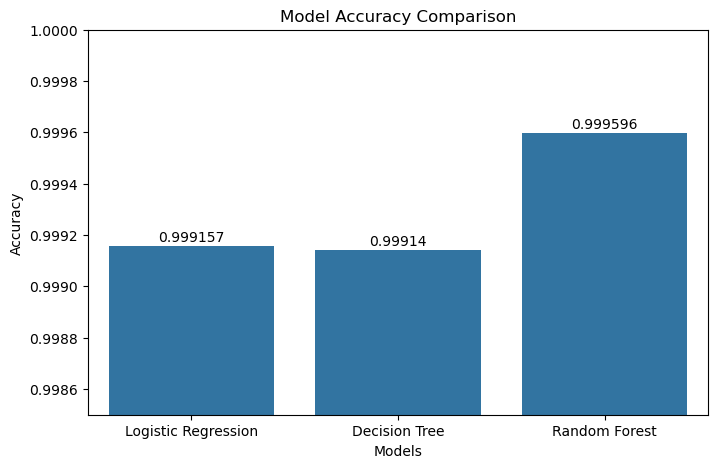

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns

# Model names
models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest'
]

# Accuracy values
accuracies = [
    0.999157,
    0.999140,
    0.999596
]

# Create graph
plt.figure(figsize=(8,5))

sns.barplot(
    x=models,
    y=accuracies
)

# Title and labels
plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy")

# Y-axis range
plt.ylim(0.9985, 1.0000)

# Show values on bars
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.00002, str(round(v,6)), ha='center')

plt.show()

## Step 17: Conclusion Cell

In [65]:
print("Random Forest performed best in detecting fraudulent transactions.")

Random Forest performed best in detecting fraudulent transactions.


In [67]:
import pickle

# Save model
with open("fraud_detection_model.pkl", "wb") as file:
    pickle.dump(rf_model, file)

print("Model saved successfully!")

Model saved successfully!
